In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F #moves data forward in function
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [2]:
# Create Model Class that inherits nn.Module
class Model(nn.Module): #class = neural network, doing nn.Module means it is able to use all of these features
    #input layer with 4 features --> hidden layer 1 --> hidden layer 2 --> single output
    def __init__(self, in_features=6, h1=64, h2=32, out_features=1): #creates layers
        super().__init__() #sets up parent class initialisation of nn.Module
        self.fc1 = nn.Linear(in_features, h1) #creating hidden layer 1 here with in_features number of inputs and h1 number of outputs
        self.fc2 = nn.Linear(h1,h2) 
        self.out = nn.Linear(h2,out_features) #even for nonlinear datasets, nn.Linear is the choice here, just need to add activation later
    def forward(self,x): #function which moves data through network, x is the variable here which gets moved through
        x = F.relu(self.fc1(x)) #Activation ReLU function (Rectified Linear Unit)
        x = F.relu(self.fc2(x)) 
        x = self.out(x) #No activation function on final layer
        return x

In [3]:
import pandas as pd
import os
data_path_phi_1 = r"C:\Users\Jamie Harvey\OneDrive - The University of Manchester\Desktop\y3 individual project\Sample Data 2D - Different phi\phi1"
all_data_phi_1 = []

for i in range(10000, 10200):
    # Read nodes
    nodes_df = pd.read_csv(os.path.join(data_path_phi_1, f'nodes_{i}'),
                          sep=r'\s+', skiprows=1,
                          names=['dummy1', 'x', 'y', 'dx', 'dummy2', 'dummy3', 'dummy4']) #path join searches for file name in folder, skip header rows

    #read field data
    for t in range(2, 12):  # time snapshots (14 with active chemistry)
        fields_df = pd.read_csv(os.path.join(data_path_phi_1, f'fields_{i}_{t}'),
                               sep=r'\s+', skiprows=5, header=None,
                               names=['density', 'u', 'v', 'vorticity', 'temperature',
                                      'pressure', 'HRR', 'ms1', 'ms2', 'ms3', 'ms4',
                                      'ms5', 'ms6', 'ms7', 'ms8', 'ms9','c','dc/dx','dc/dy'])
        
        combined_phi_1 = pd.concat([nodes_df, fields_df], axis=1)
        combined_phi_1['processor'] = i
        combined_phi_1['timestep'] = t 
        combined_phi_1['phi'] = 1
        all_data_phi_1.append(combined_phi_1)

# Final DataFrame with everything
df_phi_1 = pd.concat(all_data_phi_1, ignore_index=True) #vertical merger of all processor data into a single data frame, pd.concat default is vertical so no spec needed

In [4]:

data_path_phi_05 = r"C:\Users\Jamie Harvey\OneDrive - The University of Manchester\Desktop\y3 individual project\Sample Data 2D - Different phi\phi0.5"
all_data_phi_05 = []

for i in range(10000, 10200):
    # Read nodes
    nodes_df = pd.read_csv(os.path.join(data_path_phi_05, f'nodes_{i}'),
                          sep=r'\s+', skiprows=1,
                          names=['dummy1', 'x', 'y', 'dx', 'dummy2', 'dummy3', 'dummy4']) #path join searches for file name in folder, skip header rows

    #read field data
    for t in range(2, 12): 
        fields_df = pd.read_csv(os.path.join(data_path_phi_05, f'fields_{i}_{t}'),
                               sep=r'\s+', skiprows=5, header=None,
                               names=['density', 'u', 'v', 'vorticity', 'temperature',
                                      'pressure', 'HRR', 'ms1', 'ms2', 'ms3', 'ms4',
                                      'ms5', 'ms6', 'ms7', 'ms8', 'ms9','c','dc/dx','dc/dy'])
        
        combined_phi_05 = pd.concat([nodes_df, fields_df], axis=1)
        combined_phi_05['processor'] = i
        combined_phi_05['timestep'] = t 
        combined_phi_05['phi'] = 0.5
        all_data_phi_05.append(combined_phi_05)

# Final DataFrame with everything
df_phi_05 = pd.concat(all_data_phi_05, ignore_index=True) #vertical merger of all processor data into a single data frame, pd.concat default is vertical so no spec needed

In [5]:

data_path_phi_04 = r"C:\Users\Jamie Harvey\OneDrive - The University of Manchester\Desktop\y3 individual project\Sample Data 2D - Different phi\phi0.4"
all_data_phi_04 = []

for i in range(10000, 10200):
    # Read nodes
    nodes_df = pd.read_csv(os.path.join(data_path_phi_04, f'nodes_{i}'),
                          sep=r'\s+', skiprows=1,
                          names=['dummy1', 'x', 'y', 'dx', 'dummy2', 'dummy3', 'dummy4']) #path join searches for file name in folder, skip header rows

    #read field data
    for t in range(2, 12): 
        fields_df = pd.read_csv(os.path.join(data_path_phi_04, f'fields_{i}_{t}'),
                               sep=r'\s+', skiprows=5, header=None,
                               names=['density', 'u', 'v', 'vorticity', 'temperature',
                                      'pressure', 'HRR', 'ms1', 'ms2', 'ms3', 'ms4',
                                      'ms5', 'ms6', 'ms7', 'ms8', 'ms9','c','dc/dx','dc/dy'])
        
        combined_phi_04 = pd.concat([nodes_df, fields_df], axis=1)
        combined_phi_04['processor'] = i
        combined_phi_04['timestep'] = t 
        combined_phi_04['phi'] = 0.4
        all_data_phi_04.append(combined_phi_04)

# Final DataFrame with everything
df_phi_04 = pd.concat(all_data_phi_04, ignore_index=True) #vertical merger of all processor data into a single data frame, pd.concat default is vertical so no spec needed

In [6]:
df = pd.concat([df_phi_1, df_phi_05, df_phi_04], ignore_index=True)
print(f"Final shape: {df.shape}")
df

Final shape: (4092150, 29)


,dummy1,x,y,dx,dummy2,dummy3,dummy4,density,u,v,...,ms6,ms7,ms8,ms9,c,dc/dx,dc/dy,processor,timestep,phi
0,2328,-1.921960,0.447463,0.006,0.015876,0.015876,999,0.845151,1.646973,-0.001170,...,-1.706650e-27,5.670292e-26,-1.045044e-41,0.745187,0.027933,8.301732e-06,7.146258e-06,10000,2,1.0
1,4233,-1.853835,0.447651,0.006,0.016200,0.016200,999,0.845138,1.639752,-0.000348,...,-3.017999e-27,1.032569e-25,1.862424e-38,0.745187,0.027933,4.862421e-07,1.966991e-06,10000,2,1.0
2,6482,-1.775918,0.447719,0.006,0.015247,0.015247,999,0.845127,1.631904,-0.000008,...,-3.898029e-27,1.339446e-25,9.291338e-38,0.745187,0.027933,7.598729e-06,-1.021200e-05,10000,2,1.0
3,6125,-1.787625,0.447738,0.006,0.015876,0.015876,999,0.845127,1.632888,0.000087,...,-3.824818e-27,1.329545e-25,-2.506693e-37,0.745187,0.027933,3.392028e-06,-1.156857e-05,10000,2,1.0
4,4433,-1.845683,0.447841,0.006,0.016200,0.016200,999,0.845137,1.638664,-0.000313,...,-3.151244e-27,1.087707e-25,-6.994422e-39,0.745187,0.027933,6.917993e-06,5.534105e-07,10000,2,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4092145,132345,1.860804,0.447907,0.006,0.015876,0.015876,999,0.221229,2.651287,-0.119462,...,1.509498e-08,3.319678e-07,1.283540e-07,0.759643,0.999966,3.832323e-03,-1.228482e-03,10199,11,0.4
4092146,132187,1.853980,0.448018,0.006,0.015876,0.015876,999,0.221300,2.652735,-0.120168,...,1.527610e-08,3.343729e-07,1.296361e-07,0.759620,0.999966,3.900759e-03,-1.225147e-03,10199,11,0.4
4092147,131611,1.834425,0.448094,0.006,0.013507,0.013507,999,0.221507,2.656109,-0.122138,...,1.581590e-08,3.415505e-07,1.334372e-07,0.759553,0.999965,4.131519e-03,-1.220285e-03,10199,11,0.4
4092148,130933,1.810192,0.448103,0.006,0.015876,0.015876,999,0.221765,2.659598,-0.124478,...,1.653922e-08,3.511391e-07,1.384403e-07,0.759468,0.999964,4.498885e-03,-1.211088e-03,10199,11,0.4


In [7]:
df_filtered = df[df['c'].between(0.1, 0.9)]

mask_04 = (df_filtered['phi'] == 0.4) & (df_filtered['c'] < 0.55)
mask_05 = (df_filtered['phi'] == 0.5) & (df_filtered['c'] < 0.2)
combined_mask = mask_04 | mask_05  # remove rows for both conditions
df_filtered = df_filtered[~combined_mask]

df_filtered = df_filtered[df_filtered['HRR'] >= 0]
df_filtered = df_filtered[df_filtered['HRR'] > 1]
df_filtered

,dummy1,x,y,dx,dummy2,dummy3,dummy4,density,u,v,...,ms6,ms7,ms8,ms9,c,dc/dx,dc/dy,processor,timestep,phi
74775,13603,-1.519682,0.448858,0.006,0.016200,0.016200,999,0.643156,-0.253303,-0.304697,...,-0.000054,0.000269,0.000180,0.742091,0.109531,921.163984,445.096312,10010,11,1.0
74818,13614,-1.519955,0.455250,0.006,0.015876,0.015876,999,0.582033,0.068637,-0.036908,...,-0.000030,0.000315,0.000175,0.741219,0.135701,1160.304897,451.646363,10010,11,1.0
74841,13521,-1.523765,0.459508,0.006,0.015876,0.015876,999,0.631079,0.274671,-0.043611,...,-0.000051,0.000277,0.000174,0.742057,0.111317,952.444145,302.023629,10010,11,1.0
74857,13685,-1.517704,0.461478,0.006,0.016200,0.016200,999,0.477295,0.894308,0.184728,...,0.000054,0.000374,0.000156,0.739363,0.198402,1723.772945,518.067321,10010,11,1.0
74890,13578,-1.520274,0.466651,0.006,0.015876,0.015876,999,0.505020,1.008496,0.012292,...,0.000021,0.000366,0.000161,0.739841,0.178316,1567.556890,347.762104,10010,11,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3871428,112151,1.142096,0.234366,0.006,0.011965,0.011965,999,0.366592,2.142943,0.549104,...,0.000012,0.000147,0.000035,0.746029,0.897776,42.914372,463.623025,10167,9,0.4
3871429,111827,1.129829,0.234383,0.006,0.013507,0.013507,999,0.362078,2.094696,0.558934,...,0.000015,0.000146,0.000033,0.746586,0.895361,-0.640882,487.852362,10167,9,0.4
3876989,109415,1.043910,0.248124,0.006,0.015247,0.015247,999,0.315882,1.978334,0.260531,...,0.000042,0.000107,0.000015,0.751531,0.885574,120.415158,593.660677,10168,8,0.4
3876997,109245,1.037041,0.250039,0.006,0.016200,0.016200,999,0.309972,1.998348,0.309634,...,0.000048,0.000102,0.000014,0.752014,0.888173,137.337247,600.965836,10168,8,0.4


In [8]:
#step 2 - specifying variables of interest
#For this basic model, 6 inputs, 1 output
model_variables = ['c','density','temperature','dc/dx','dc/dy','phi','HRR']
model_data = df_filtered[model_variables]

print(model_data)

X=model_data[['c','density','temperature','dc/dx','dc/dy','phi']].values
y=model_data['HRR'].values

                c   density  temperature        dc/dx       dc/dy  phi  \
74775    0.109531  0.643156   399.912387   921.163984  445.096312  1.0   
74818    0.135701  0.582033   443.961045  1160.304897  451.646363  1.0   
74841    0.111317  0.631079   407.581074   952.444145  302.023629  1.0   
74857    0.198402  0.477295   547.322727  1723.772945  518.067321  1.0   
74890    0.178316  0.505020   515.575997  1567.556890  347.762104  1.0   
...           ...       ...          ...          ...         ...  ...   
3871428  0.897776  0.366592   886.664123    42.914372  463.623025  0.4   
3871429  0.895361  0.362078   896.880155    -0.640882  487.852362  0.4   
3876989  0.885574  0.315882  1019.384686   120.415158  593.660677  0.4   
3876997  0.888173  0.309972  1038.031745   137.337247  600.965836  0.4   
3877022  0.895618  0.300571  1069.815322   144.099286  588.076900  0.4   

                  HRR  
74775    3.828561e+08  
74818    6.409277e+08  
74841    3.971411e+08  
74857    6.5442

In [9]:
from sklearn.model_selection import train_test_split
phi_col = 5

X_train_unscaled, X_unseen_unscaled, y_train_unscaled, y_unseen_unscaled = train_test_split(X, y, test_size=0.2, random_state=11, stratify=model_data['phi'])

X_test_unscaled, X_val_unscaled, y_test_unscaled, y_val_unscaled = train_test_split(X_unseen_unscaled, y_unseen_unscaled, test_size=0.5, random_state=11,stratify=X_unseen_unscaled[:, phi_col])

#scale data
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train_unscaled) #apply normalisation
X_val = scaler_X.transform(X_val_unscaled)   
X_test = scaler_X.transform(X_test_unscaled)        

y_train_log = np.log1p(np.abs(y_train_unscaled))
y_val_log = np.log1p(np.abs(y_val_unscaled))
y_test_log = np.log1p(np.abs(y_test_unscaled))    
y_train = scaler_y.fit_transform(y_train_log.reshape(-1, 1))
y_val = scaler_y.transform(y_val_log.reshape(-1, 1))
y_test = scaler_y.transform(y_test_log.reshape(-1, 1))   

#convert numpy arrays into tensors for use in PyTorch
X_train = torch.FloatTensor(X_train).to(device) #for floats
X_val = torch.FloatTensor(X_val).to(device)
X_test = torch.FloatTensor(X_test).to(device)
y_train = torch.FloatTensor(y_train).view(-1,1).to(device) #reshape
y_val = torch.FloatTensor(y_val).view(-1,1).to(device)
y_test = torch.FloatTensor(y_test).view(-1,1).to(device) #.to(device) moves to GPU 

In [10]:
#batch training
from torch.utils.data import DataLoader, TensorDataset
batch_size=32768
dataset=TensorDataset(X_train,y_train) 
train_loader=DataLoader(dataset,batch_size=batch_size,shuffle=True)#shuffle improves generalisation performance

In [11]:
from codecarbon import EmissionsTracker #carbon emission tracker
import time

tracker = EmissionsTracker()
tracker.start()
start_training=time.time()

[codecarbon WARNING @ 01:11:50] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 01:11:51] [setup] RAM Tracking...
[codecarbon INFO @ 01:11:51] [setup] CPU Tracking...
[codecarbon WARNING @ 01:11:52] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 01:11:52] CPU Model on constant consumption mode: 12th Gen Intel(R) Core(TM) i7-12700H
[codecarbon WARNING @ 01:11:52] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 01:11:52] [setup] GPU Tracking...
[codecarbon INFO @ 01:11:52] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 01:11:52] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 01:11:52] >>> Tracker's metadata:
[code

In [12]:
torch.manual_seed(11)
model=Model().to(device)
criterion = nn.MSELoss() #Mean Squared Error for regression
optimiser = torch.optim.Adam(model.parameters(),lr=0.001) #choose optimiser and learning rate, model parameters are the layers

In [13]:
epochs=800
train_losses=[] #list which will be added to
val_losses=[]

# Early stopping setup
best_val_loss = float('inf')
patience_counter = 0
patience = 30
min_improvement = 0.02  # 2% minimum improvement
for i in range(epochs):
    model.train() #training mode
    batch_losses=[]
    for X_batch,y_batch in train_loader:
        optimiser.zero_grad() #resets gradient calculation (neccesary)
        #go forward and predict
        y_pred=model.forward(X_batch) #get predicted results
        #Measure loss
        loss = criterion(y_pred,y_batch)
        #Back propagation (fine tuning of neuron parameters)
        loss.backward() #works out gradient for each weight (how much each weight contributed to error)
        optimiser.step() #gradient descent to update weight based on optimiser (optimiser determines how much to change weight by)
        batch_losses.append(loss.item())
        
    train_loss=np.mean(batch_losses)
    train_losses.append(train_loss)

    #validation
    model.eval()  # evaluation mode
    with torch.no_grad():
        y_val_pred = model.forward(X_val)
        val_loss = criterion(y_val_pred, y_val)
        val_losses.append(val_loss.detach().cpu().numpy())

    # Early stopping check
    if val_loss < best_val_loss * (1 - min_improvement):
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {i}, best val loss: {best_val_loss:.5f}")
        break
        
    #print every 50 epochs
    if i % 5 == 0: #% operator gives remainder 
        print(f'Epoch:{i}, Training loss: {train_loss}, Validation Loss: {val_loss}')

model.load_state_dict(torch.load('best_model.pt',weights_only=True))
print("Best model loaded")

Epoch:0, Training loss: 0.9509841352701187, Validation Loss: 0.8695402145385742


[codecarbon INFO @ 01:12:12] Energy consumed for RAM : 0.000089 kWh. RAM Power : 20.0 W


Epoch:5, Training loss: 0.5282151624560356, Validation Loss: 0.4719628095626831


[codecarbon INFO @ 01:12:13] Delta energy consumed for CPU with cpu_load : 0.000021 kWh, power : 4.674681626142857 W
[codecarbon INFO @ 01:12:13] Energy consumed for All CPU : 0.000021 kWh
[codecarbon INFO @ 01:12:13] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 01:12:13] Energy consumed for all GPUs : 0.000055 kWh. Total GPU Power : 11.882702086208859 W
[codecarbon INFO @ 01:12:13] 0.000165 kWh of electricity and 0.000000 L of water were used since the beginning.


Epoch:10, Training loss: 0.21519570797681808, Validation Loss: 0.19053849577903748


...

Epoch:190, Training loss: 0.02777268923819065, Validation Loss: 0.025664281100034714
Epoch:195, Training loss: 0.027030886616557837, Validation Loss: 0.02540740557014942


[codecarbon INFO @ 01:19:14] Energy consumed for RAM : 0.002310 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 01:19:14] Delta energy consumed for CPU with cpu_load : 0.000019 kWh, power : 4.8074095962 W
[codecarbon INFO @ 01:19:14] Energy consumed for All CPU : 0.000578 kWh
[codecarbon INFO @ 01:19:14] Energy consumed for all GPUs : 0.001594 kWh. Total GPU Power : 13.09335321403495 W
[codecarbon INFO @ 01:19:14] 0.004481 kWh of electricity and 0.000000 L of water were used since the beginning.


Epoch:200, Training loss: 0.028141422662883997, Validation Loss: 0.025370394811034203


[codecarbon INFO @ 01:19:29] Energy consumed for RAM : 0.002391 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 01:19:30] Delta energy consumed for CPU with cpu_load : 0.000022 kWh, power : 5.513316798214286 W
[codecarbon INFO @ 01:19:30] Energy consumed for All CPU : 0.000600 kWh
[codecarbon INFO @ 01:19:30] Energy consumed for all GPUs : 0.001650 kWh. Total GPU Power : 13.192101326135875 W
[codecarbon INFO @ 01:19:30] 0.004641 kWh of electricity and 0.000000 L of water were used since the beginning.


Early stopping at epoch 204, best val loss: 0.02580
Best model loaded


In [14]:
training_time=time.time()-start_training
print(f"Training time: {training_time} secs")

training_emissions=tracker.stop()
print(f"Training Emissions: {training_emissions} kg CO2")

[codecarbon INFO @ 01:19:33] Energy consumed for RAM : 0.002406 kWh. RAM Power : 20.0 W


Training time: 455.6724269390106 secs


[codecarbon INFO @ 01:19:33] Delta energy consumed for CPU with cpu_load : 0.000004 kWh, power : 5.368216198500001 W
[codecarbon INFO @ 01:19:33] Energy consumed for All CPU : 0.000604 kWh
[codecarbon INFO @ 01:19:33] Energy consumed for all GPUs : 0.001663 kWh. Total GPU Power : 13.699914878491638 W
[codecarbon INFO @ 01:19:33] 0.004673 kWh of electricity and 0.000000 L of water were used since the beginning.


Training Emissions: 0.0011101479660492388 kg CO2


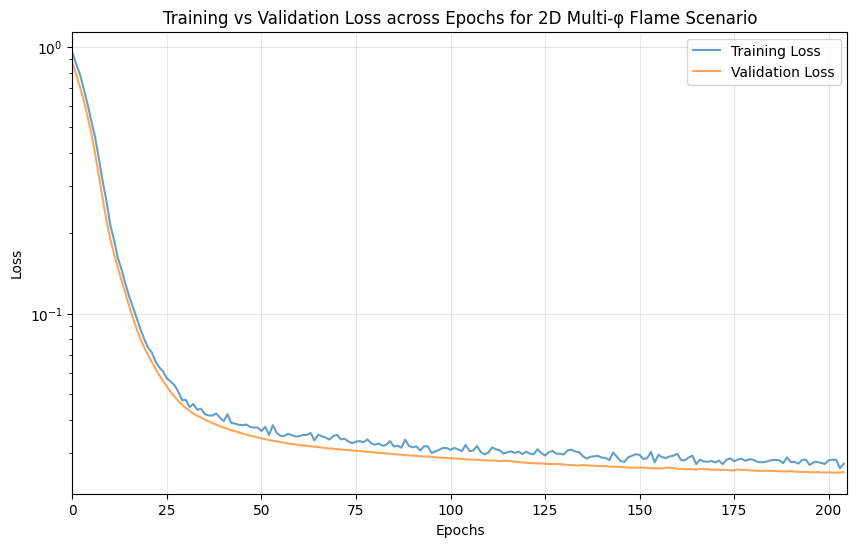

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', alpha=0.7)
plt.plot(val_losses, label='Validation Loss', alpha=0.7)
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xlim(0,len(train_losses))
plt.title('Training vs Validation Loss across Epochs for 2D Multi-φ Flame Scenario')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
start_inference=time.time()

In [17]:
#Evaluate Model
with torch.no_grad():
    y_pred_scaled = model(X_test)
    
    y_pred_log = scaler_y.inverse_transform(y_pred_scaled.cpu().numpy().reshape(-1, 1))
    y_test_log = scaler_y.inverse_transform(y_test.cpu().numpy().reshape(-1, 1))

    y_pred_actual = np.sign(y_pred_log) * np.expm1(np.abs(y_pred_log))
    y_test_actual = np.sign(y_test_log) * np.expm1(np.abs(y_test_log))

In [18]:
inference_time=time.time()-start_inference
print(f"Inference time: {inference_time} secs, Inference time per sample: {inference_time/len(X_test)*1000:.4f}ms")

Inference time: 0.02197408676147461 secs, Inference time per sample: 0.0017ms


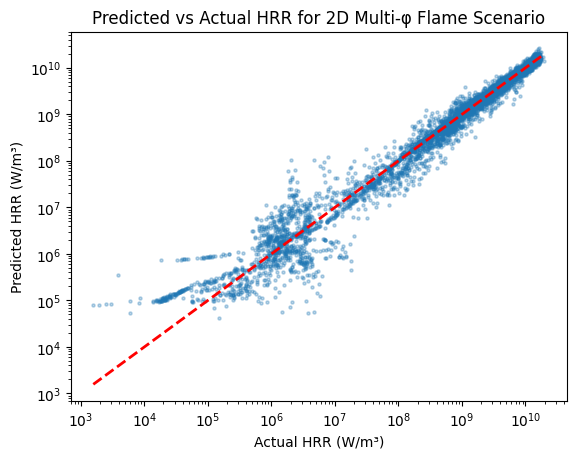

In [19]:
y_pred_np = y_pred_actual.flatten()
y_test_np = y_test_actual.flatten()

plt.scatter(y_test_np,y_pred_np,alpha=0.3, s=5)
plt.title("Predicted vs Actual HRR for 2D Multi-φ Flame Scenario")
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Actual HRR (W/m³)')
plt.ylabel('Predicted HRR (W/m³)')
plt.plot([y_test_np.min(), y_test_np.max()],   # x-coordinates (start, end)
         [y_test_np.min(), y_test_np.max()],   # y-coordinates (start, end)
         'r--', lw=2)
plt.show()

In [20]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

r2 = r2_score(y_test_np, y_pred_np)
mae = mean_absolute_error(y_test_np, y_pred_np)
rmse = np.sqrt(mean_squared_error(y_test_np, y_pred_np))
mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual) * 100
nmse = mean_squared_error(y_test_np, y_pred_np)/np.var(y_test_np)

#new metric - normalised MSE


print(f"\nR² Score: {r2:.4f}")
print(f"MAE:      {mae:.2f}")
print(f"RMSE:     {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")  
print(f"NMSE: {nmse:.5f}") 


R² Score: 0.9738
MAE:      278485824.00
RMSE:     641756647.96
MAPE: 27.53%
NMSE: 0.02624
